# 04 — Baseline Analysis

This notebook analyses model performance under the full-data baseline condition before sparsity is introduced.

The analysis:

- summarises baseline NDCG, Recall, and MRR;
- reports mean and standard deviation across stochastic seeds;
- ranks models within each dataset;
- examines ranking consistency across recommendation-list lengths;
- examines baseline seed variability;
- compares baseline model rankings between MovieLens and Amazon;
- exports clean tables and figures for later dissertation use.

NDCG@10 is treated as the primary metric. Recall@10 and MRR@10 are used as supporting metrics.

## 1.2 Setup

Load required libraries, locate the repository, and create baseline figure and table directories.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ---------------------------------------------------------------------
# Locate repository root
# ---------------------------------------------------------------------

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "results").exists()
            and (candidate / "scripts").exists()
            and (candidate / "configs").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root."
    )


ROOT = find_repo_root()

FIGURE_DIR = ROOT / "results" / "figures" / "baseline"
TABLE_DIR = ROOT / "results" / "tables" / "baseline"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root : {ROOT}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Table directory : {TABLE_DIR}")


# ---------------------------------------------------------------------
# Plot defaults
# ---------------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (9, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.25,
})

Repository root : C:\Research Project\recommender-sparsity-honours
Figure directory: C:\Research Project\recommender-sparsity-honours\results\figures\baseline
Table directory : C:\Research Project\recommender-sparsity-honours\results\tables\baseline


## 1.3 Verification status

Confirm that the final experiment set passed the verification notebook before analysing results.

In [2]:
verification_path = (
    ROOT
    / "results"
    / "verification"
    / "verification_summary.json"
)

if not verification_path.exists():
    raise FileNotFoundError(
        "verification_summary.json was not found. "
        "Run 03_results_verification.ipynb first."
    )

with open(
    verification_path,
    "r",
    encoding="utf-8",
) as f:
    verification = json.load(f)

print("Verification summary")
print("--------------------")
print(f"PASS : {verification['pass']}")
print(f"WARN : {verification['warn']}")
print(f"FAIL : {verification['fail']}")

if verification["fail"] > 0:
    raise RuntimeError(
        "Final result verification contains FAIL checks. "
        "Resolve these before baseline analysis."
    )

print("\nVerification passed sufficiently for analysis.")

Verification summary
--------------------
PASS : 362
WARN : 2
FAIL : 0

Verification passed sufficiently for analysis.


# 2. Baseline Data Preparation

## 2.1 Load final results

Load the verified MovieLens and Amazon final experiment tables and retain only the 100% baseline condition.

In [3]:
result_files = sorted(
    (ROOT / "results" / "processed").rglob(
        "all_final_results.csv"
    )
)

if not result_files:
    raise FileNotFoundError(
        "No all_final_results.csv files found."
    )

frames = []

for path in result_files:
    df = pd.read_csv(path)
    df["_source_file"] = str(path.relative_to(ROOT))
    frames.append(df)

results = pd.concat(
    frames,
    ignore_index=True,
)

results["model_seed"] = pd.to_numeric(
    results["model_seed"],
    errors="coerce",
).astype("Int64")

results["retention_level"] = pd.to_numeric(
    results["retention_level"],
    errors="coerce",
).astype("Int64")


baseline = results[
    (results["scenario"] == "baseline")
    & (results["retention_level"] == 100)
].copy()


print(f"All final rows : {len(results)}")
print(f"Baseline rows  : {len(baseline)}")

display(
    baseline.groupby("dataset")
    .agg(
        rows=("model", "size"),
        models=("model", "nunique"),
    )
)


assert len(baseline) == 48
assert (
    baseline.groupby("dataset").size()
    == 24
).all()

assert baseline["model"].nunique() == 10
assert baseline["dataset"].nunique() == 2

print("\nBaseline experiment set loaded correctly.")

All final rows : 480
Baseline rows  : 48


,rows,models
dataset,,
amazon,24,10
movielens,24,10



Baseline experiment set loaded correctly.


## 2.2 Model metadata

Assign each evaluated model to its recommendation family for later interpretation.

In [4]:
MODEL_FAMILY = {
    "Pop": "Non-personalized",
    "ItemKNN": "Classical",
    "BPR": "Classical",
    "EASE": "Linear",
    "NeuMF": "Neural",
    "MultiVAE": "Neural",
    "GRU4Rec": "Sequential",
    "SASRec": "Sequential",
    "BERT4Rec": "Sequential",
    "LightGCN": "Graph",
}

MODEL_ORDER = [
    "Pop",
    "ItemKNN",
    "BPR",
    "EASE",
    "NeuMF",
    "MultiVAE",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec",
    "LightGCN",
]

baseline["model_family"] = baseline[
    "model"
].map(MODEL_FAMILY)

assert baseline["model_family"].notna().all()

display(
    baseline[
        ["model", "model_family"]
    ]
    .drop_duplicates()
    .sort_values("model_family")
    .reset_index(drop=True)
)

,model,model_family
0,BPR,Classical
1,ItemKNN,Classical
2,LightGCN,Graph
3,EASE,Linear
4,MultiVAE,Neural
5,NeuMF,Neural
6,Pop,Non-personalized
7,BERT4Rec,Sequential
8,GRU4Rec,Sequential
9,SASRec,Sequential


## 2.3 Baseline summary statistics

Calculate mean, sample standard deviation, minimum, maximum, run count, and model rank for the primary test metrics.

Deterministic models have one run, so their standard deviation is left undefined rather than reported as zero.

In [5]:
PRIMARY_METRICS = [
    "test_ndcg@10",
    "test_recall@10",
    "test_mrr@10",
]


summary_rows = []

for (dataset, model), group in baseline.groupby(
    ["dataset", "model"]
):

    row = {
        "dataset": dataset,
        "model": model,
        "model_family": MODEL_FAMILY[model],
        "runs": len(group),
    }

    for metric in PRIMARY_METRICS:
        values = group[metric].astype(float)

        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = (
            values.std(ddof=1)
            if len(values) > 1
            else np.nan
        )
        row[f"{metric}_min"] = values.min()
        row[f"{metric}_max"] = values.max()

    summary_rows.append(row)


baseline_summary = pd.DataFrame(
    summary_rows
)


# Add rankings within each dataset.
for metric in PRIMARY_METRICS:
    baseline_summary[
        f"{metric}_rank"
    ] = (
        baseline_summary.groupby("dataset")[
            f"{metric}_mean"
        ]
        .rank(
            method="min",
            ascending=False,
        )
        .astype(int)
    )


baseline_summary = baseline_summary.sort_values(
    [
        "dataset",
        "test_ndcg@10_rank",
    ]
).reset_index(drop=True)


display(baseline_summary)

,dataset,model,model_family,runs,test_ndcg@10_mean,test_ndcg@10_std,test_ndcg@10_min,test_ndcg@10_max,test_recall@10_mean,test_recall@10_std,test_recall@10_min,test_recall@10_max,test_mrr@10_mean,test_mrr@10_std,test_mrr@10_min,test_mrr@10_max,test_ndcg@10_rank,test_recall@10_rank,test_mrr@10_rank
0,amazon,SASRec,Sequential,3,0.046315,0.000368,0.046033,0.046731,0.096300,0.001948,0.094113,0.097851,0.031080,0.001087,0.030220,0.032302,1,1,2
1,amazon,GRU4Rec,Sequential,3,0.044938,0.000974,0.043828,0.045650,0.084983,0.001570,0.083248,0.086307,0.032841,0.000800,0.031920,0.033366,2,2,1
2,amazon,EASE,Linear,1,0.040555,NaN,0.040555,0.040555,0.072666,NaN,0.072666,0.072666,0.030816,NaN,0.030816,0.030816,3,4,3
3,amazon,BERT4Rec,Sequential,3,0.039125,0.000320,0.038812,0.039451,0.074291,0.000951,0.073502,0.075347,0.028502,0.000269,0.028199,0.028714,4,3,4
4,amazon,LightGCN,Graph,3,0.035857,0.000431,0.035460,0.036316,0.065933,0.000523,0.065444,0.066485,0.026761,0.000412,0.026389,0.027203,5,5,5
5,amazon,BPR,Classical,3,0.035450,0.000467,0.035025,0.035949,0.065002,0.001148,0.064293,0.066327,0.026504,0.000320,0.026145,0.026761,6,6,6
6,amazon,MultiVAE,Neural,3,0.034618,0.000439,0.034172,0.035049,0.064361,0.000593,0.063867,0.065018,0.025627,0.000393,0.025209,0.025989,7,7,7
7,amazon,NeuMF,Neural,3,0.024331,0.000272,0.024018,0.024511,0.046247,0.000587,0.045606,0.046757,0.017706,0.000180,0.017499,0.017829,8,8,9
8,amazon,ItemKNN,Classical,1,0.024051,NaN,0.024051,0.024051,0.043934,NaN,0.043934,0.043934,0.018025,NaN,0.018025,0.018025,9,9,8
9,amazon,Pop,Non-personalized,1,0.016255,NaN,0.016255,0.016255,0.032012,NaN,0.032012,0.032012,0.011597,NaN,0.011597,0.011597,10,10,10


# 3. MovieLens Baseline

## 3.1 Baseline performance

Summarise MovieLens baseline performance using NDCG@10 as the primary ranking metric.

In [6]:
movielens_summary = (
    baseline_summary[
        baseline_summary["dataset"]
        == "movielens"
    ]
    .copy()
    .sort_values("test_ndcg@10_rank")
)


movielens_table = movielens_summary[
    [
        "model",
        "model_family",
        "runs",
        "test_ndcg@10_mean",
        "test_ndcg@10_std",
        "test_recall@10_mean",
        "test_recall@10_std",
        "test_mrr@10_mean",
        "test_mrr@10_std",
        "test_ndcg@10_rank",
    ]
].copy()


movielens_table.columns = [
    "Model",
    "Family",
    "Runs",
    "NDCG@10 Mean",
    "NDCG@10 SD",
    "Recall@10 Mean",
    "Recall@10 SD",
    "MRR@10 Mean",
    "MRR@10 SD",
    "NDCG@10 Rank",
]


display(
    movielens_table.style.format({
        "NDCG@10 Mean": "{:.6f}",
        "NDCG@10 SD": "{:.6f}",
        "Recall@10 Mean": "{:.6f}",
        "Recall@10 SD": "{:.6f}",
        "MRR@10 Mean": "{:.6f}",
        "MRR@10 SD": "{:.6f}",
    })
)

,Model,Family,Runs,NDCG@10 Mean,NDCG@10 SD,Recall@10 Mean,Recall@10 SD,MRR@10 Mean,MRR@10 SD,NDCG@10 Rank
10,SASRec,Sequential,3,0.119079,0.002283,0.223898,0.001195,0.087307,0.003045,1
11,GRU4Rec,Sequential,3,0.112553,0.001456,0.210032,0.004928,0.083042,0.001652,2
12,BERT4Rec,Sequential,3,0.106708,0.002586,0.212463,0.002713,0.074836,0.002591,3
13,EASE,Linear,1,0.045156,nan,0.090322,nan,0.031692,nan,4
14,MultiVAE,Neural,3,0.039195,0.000607,0.081151,0.001066,0.026741,0.000433,5
15,LightGCN,Graph,3,0.038068,0.000704,0.079604,0.002226,0.025681,0.000365,6
16,BPR,Classical,3,0.038047,0.001206,0.079218,0.002738,0.025787,0.000800,7
17,ItemKNN,Classical,1,0.037286,nan,0.075572,nan,0.025903,nan,8
18,NeuMF,Neural,3,0.031950,0.000887,0.067120,0.001868,0.021448,0.000636,9
19,Pop,Non-personalized,1,0.019158,nan,0.039443,nan,0.013127,nan,10


## 3.2 MovieLens NDCG@10

Compare baseline NDCG@10 across all models. Error bars show one sample standard deviation for stochastic models.

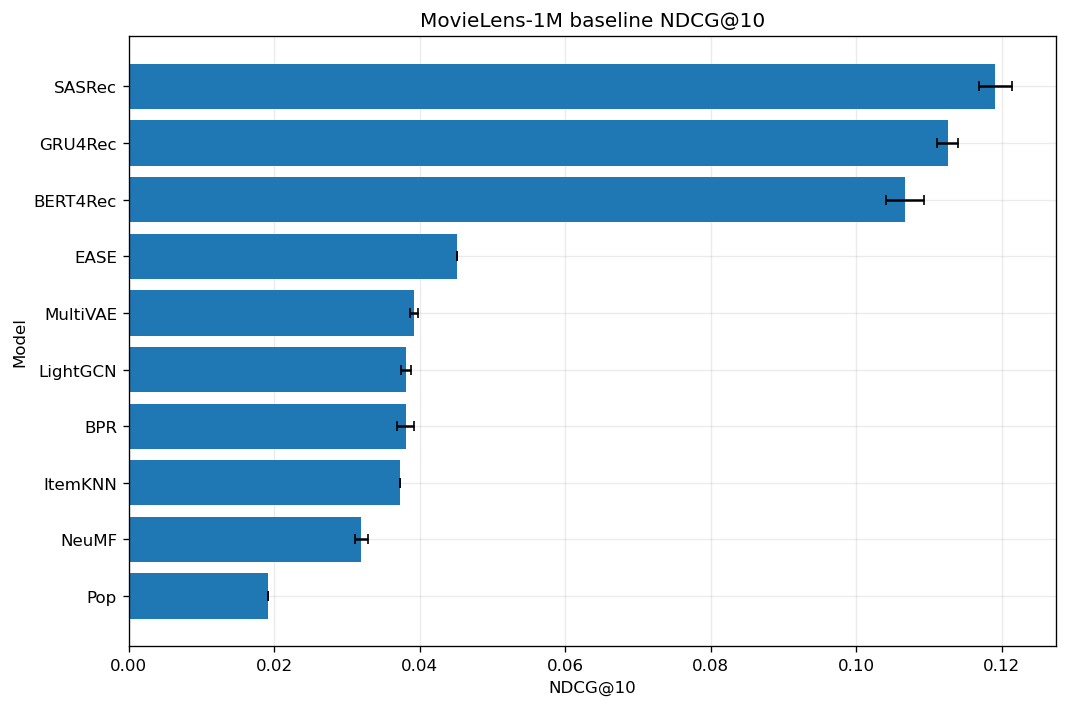

In [7]:
def save_figure(fig, filename):
    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        bbox_inches="tight",
    )

    fig.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )


def plot_baseline_metric(
    summary,
    dataset,
    metric,
    metric_label,
    title,
    filename,
):

    subset = (
        summary[
            summary["dataset"] == dataset
        ]
        .copy()
        .sort_values(
            f"{metric}_mean",
            ascending=True,
        )
    )

    means = subset[
        f"{metric}_mean"
    ].to_numpy()

    stds = (
        subset[f"{metric}_std"]
        .fillna(0)
        .to_numpy()
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.barh(
        subset["model"],
        means,
        xerr=stds,
        capsize=3,
    )

    ax.set_xlabel(metric_label)
    ax.set_ylabel("Model")
    ax.set_title(title)

    ax.set_xlim(
        left=0
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()


plot_baseline_metric(
    baseline_summary,
    dataset="movielens",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    title="MovieLens-1M baseline NDCG@10",
    filename="movielens_baseline_ndcg10",
)

## 3.3 MovieLens Recall@10

Use Recall@10 as a supporting measure of whether the NDCG@10 ranking is consistent with recommendation hit coverage.

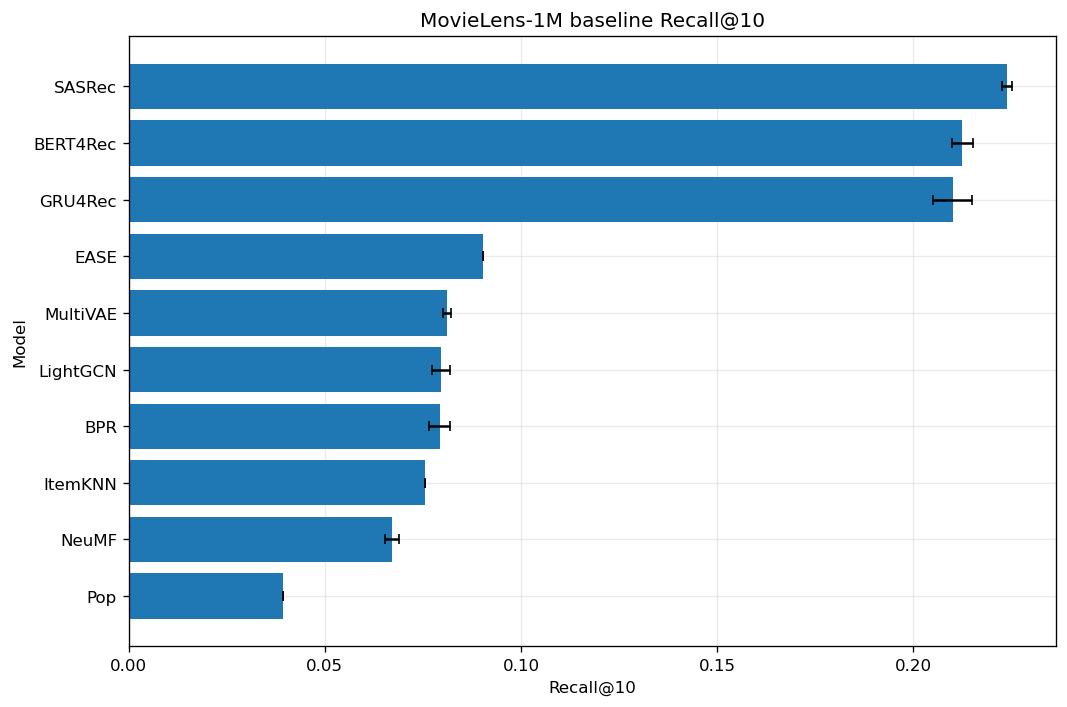

In [8]:
plot_baseline_metric(
    baseline_summary,
    dataset="movielens",
    metric="test_recall@10",
    metric_label="Recall@10",
    title="MovieLens-1M baseline Recall@10",
    filename="movielens_baseline_recall10",
)

## 3.4 MovieLens MRR@10

Compare how highly the held-out relevant item is ranked when it appears in the recommendation list.

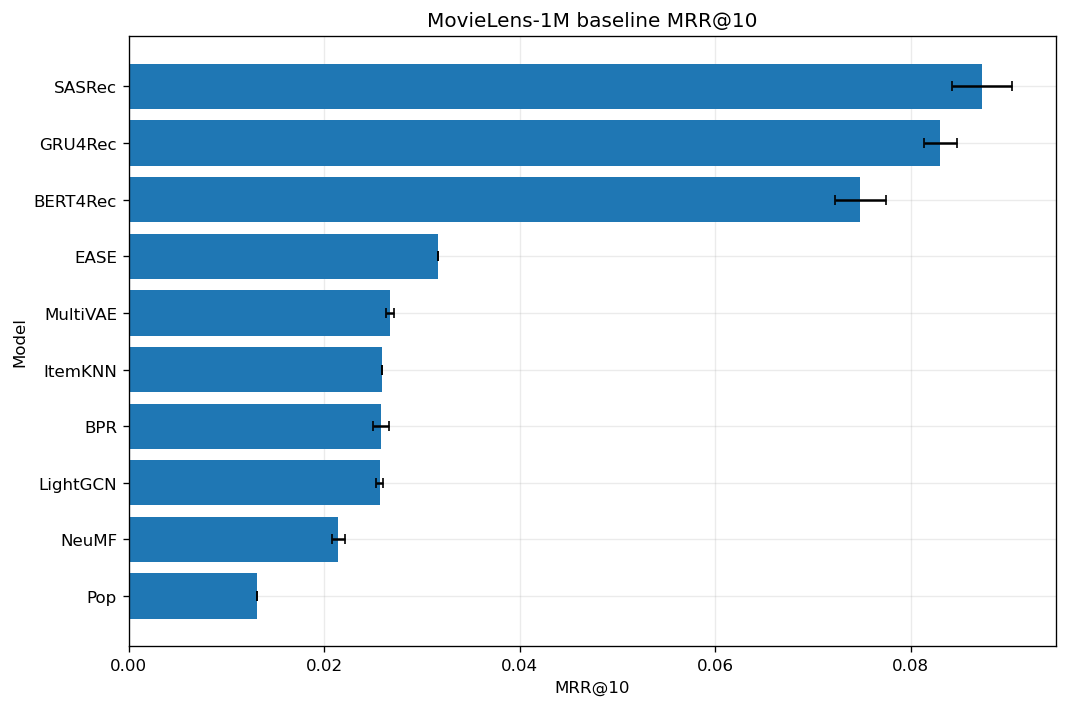

In [9]:
plot_baseline_metric(
    baseline_summary,
    dataset="movielens",
    metric="test_mrr@10",
    metric_label="MRR@10",
    title="MovieLens-1M baseline MRR@10",
    filename="movielens_baseline_mrr10",
)

## 3.5 Ranking consistency across K

Compare model rankings under NDCG@5, NDCG@10, and NDCG@20.

In [10]:
def create_rank_by_k_table(
    baseline_df,
    dataset,
    metric="ndcg",
):

    subset = baseline_df[
        baseline_df["dataset"] == dataset
    ]

    rows = []

    for model, group in subset.groupby("model"):

        row = {
            "model": model,
            "family": MODEL_FAMILY[model],
        }

        for k in [5, 10, 20]:
            column = f"test_{metric}@{k}"
            row[f"{metric.upper()}@{k}"] = (
                group[column].mean()
            )

        rows.append(row)

    table = pd.DataFrame(rows)

    for k in [5, 10, 20]:
        metric_column = f"{metric.upper()}@{k}"

        table[f"Rank@{k}"] = (
            table[metric_column]
            .rank(
                method="min",
                ascending=False,
            )
            .astype(int)
        )

    return table.sort_values(
        "Rank@10"
    ).reset_index(drop=True)


movielens_ndcg_k = create_rank_by_k_table(
    baseline,
    "movielens",
    metric="ndcg",
)

display(
    movielens_ndcg_k.style.format({
        "NDCG@5": "{:.6f}",
        "NDCG@10": "{:.6f}",
        "NDCG@20": "{:.6f}",
    })
)

,model,family,NDCG@5,NDCG@10,NDCG@20,Rank@5,Rank@10,Rank@20
0,SASRec,Sequential,0.093748,0.119079,0.145713,1,1,1
1,GRU4Rec,Sequential,0.088337,0.112553,0.137308,2,2,2
2,BERT4Rec,Sequential,0.079638,0.106708,0.133973,3,3,3
3,EASE,Linear,0.032601,0.045156,0.061191,4,4,4
4,MultiVAE,Neural,0.027150,0.039195,0.053790,5,5,5
5,LightGCN,Graph,0.026700,0.038068,0.052614,6,6,7
6,BPR,Classical,0.026360,0.038047,0.052876,8,7,6
7,ItemKNN,Classical,0.026617,0.037286,0.050919,7,8,8
8,NeuMF,Neural,0.022227,0.031950,0.045409,9,9,9
9,Pop,Non-personalized,0.013566,0.019158,0.028064,10,10,10


## 3.6 Seed variability

Examine baseline run-to-run variation for stochastic MovieLens models. Deterministic models are excluded because they have only one run.

In [11]:
def create_seed_variability_table(
    summary,
    dataset,
):

    table = (
        summary[
            (summary["dataset"] == dataset)
            & (summary["runs"] > 1)
        ]
        [
            [
                "model",
                "model_family",
                "runs",
                "test_ndcg@10_mean",
                "test_ndcg@10_std",
                "test_ndcg@10_min",
                "test_ndcg@10_max",
            ]
        ]
        .copy()
    )

    table["ndcg_range"] = (
        table["test_ndcg@10_max"]
        - table["test_ndcg@10_min"]
    )

    table["coefficient_of_variation_percent"] = (
        table["test_ndcg@10_std"]
        / table["test_ndcg@10_mean"]
        * 100
    )

    return table.sort_values(
        "test_ndcg@10_std",
        ascending=False,
    ).reset_index(drop=True)


movielens_seed_variability = (
    create_seed_variability_table(
        baseline_summary,
        "movielens",
    )
)

display(
    movielens_seed_variability.style.format({
        "test_ndcg@10_mean": "{:.6f}",
        "test_ndcg@10_std": "{:.6f}",
        "test_ndcg@10_min": "{:.6f}",
        "test_ndcg@10_max": "{:.6f}",
        "ndcg_range": "{:.6f}",
        "coefficient_of_variation_percent": "{:.2f}%",
    })
)

,model,model_family,runs,test_ndcg@10_mean,test_ndcg@10_std,test_ndcg@10_min,test_ndcg@10_max,ndcg_range,coefficient_of_variation_percent
0,BERT4Rec,Sequential,3,0.106708,0.002586,0.104292,0.109435,0.005143,2.42%
1,SASRec,Sequential,3,0.119079,0.002283,0.117710,0.121715,0.004005,1.92%
2,GRU4Rec,Sequential,3,0.112553,0.001456,0.111683,0.114234,0.002551,1.29%
3,BPR,Classical,3,0.038047,0.001206,0.036814,0.039224,0.002410,3.17%
4,NeuMF,Neural,3,0.031950,0.000887,0.031305,0.032961,0.001656,2.77%
5,LightGCN,Graph,3,0.038068,0.000704,0.037351,0.038758,0.001407,1.85%
6,MultiVAE,Neural,3,0.039195,0.000607,0.038802,0.039895,0.001093,1.55%


## 3.7 MovieLens baseline findings

Record the main observations after reviewing the tables and figures:

- Which model achieves the highest NDCG@10?
- Are the strongest models also strongest for Recall@10 and MRR@10?
- Which non-sequential model performs best?
- Are model rankings stable across K = 5, 10, and 20?
- How much seed variability is present?
- Are any differences sufficiently small that the models should be described as similar rather than clearly separated?

These observations will later be converted into the MovieLens baseline subsection of the Results chapter.

# 4. Amazon Baseline

## 4.1 Baseline performance

Summarise Amazon Video Games baseline performance using NDCG@10 as the primary ranking metric.

In [12]:
amazon_summary = (
    baseline_summary[
        baseline_summary["dataset"]
        == "amazon"
    ]
    .copy()
    .sort_values("test_ndcg@10_rank")
)


amazon_table = amazon_summary[
    [
        "model",
        "model_family",
        "runs",
        "test_ndcg@10_mean",
        "test_ndcg@10_std",
        "test_recall@10_mean",
        "test_recall@10_std",
        "test_mrr@10_mean",
        "test_mrr@10_std",
        "test_ndcg@10_rank",
    ]
].copy()


amazon_table.columns = [
    "Model",
    "Family",
    "Runs",
    "NDCG@10 Mean",
    "NDCG@10 SD",
    "Recall@10 Mean",
    "Recall@10 SD",
    "MRR@10 Mean",
    "MRR@10 SD",
    "NDCG@10 Rank",
]


display(
    amazon_table.style.format({
        "NDCG@10 Mean": "{:.6f}",
        "NDCG@10 SD": "{:.6f}",
        "Recall@10 Mean": "{:.6f}",
        "Recall@10 SD": "{:.6f}",
        "MRR@10 Mean": "{:.6f}",
        "MRR@10 SD": "{:.6f}",
    })
)

,Model,Family,Runs,NDCG@10 Mean,NDCG@10 SD,Recall@10 Mean,Recall@10 SD,MRR@10 Mean,MRR@10 SD,NDCG@10 Rank
0,SASRec,Sequential,3,0.046315,0.000368,0.096300,0.001948,0.031080,0.001087,1
1,GRU4Rec,Sequential,3,0.044938,0.000974,0.084983,0.001570,0.032841,0.000800,2
2,EASE,Linear,1,0.040555,nan,0.072666,nan,0.030816,nan,3
3,BERT4Rec,Sequential,3,0.039125,0.000320,0.074291,0.000951,0.028502,0.000269,4
4,LightGCN,Graph,3,0.035857,0.000431,0.065933,0.000523,0.026761,0.000412,5
5,BPR,Classical,3,0.035450,0.000467,0.065002,0.001148,0.026504,0.000320,6
6,MultiVAE,Neural,3,0.034618,0.000439,0.064361,0.000593,0.025627,0.000393,7
7,NeuMF,Neural,3,0.024331,0.000272,0.046247,0.000587,0.017706,0.000180,8
8,ItemKNN,Classical,1,0.024051,nan,0.043934,nan,0.018025,nan,9
9,Pop,Non-personalized,1,0.016255,nan,0.032012,nan,0.011597,nan,10


## 4.2 Amazon NDCG@10

Compare full-data Amazon NDCG@10 across all ten models.

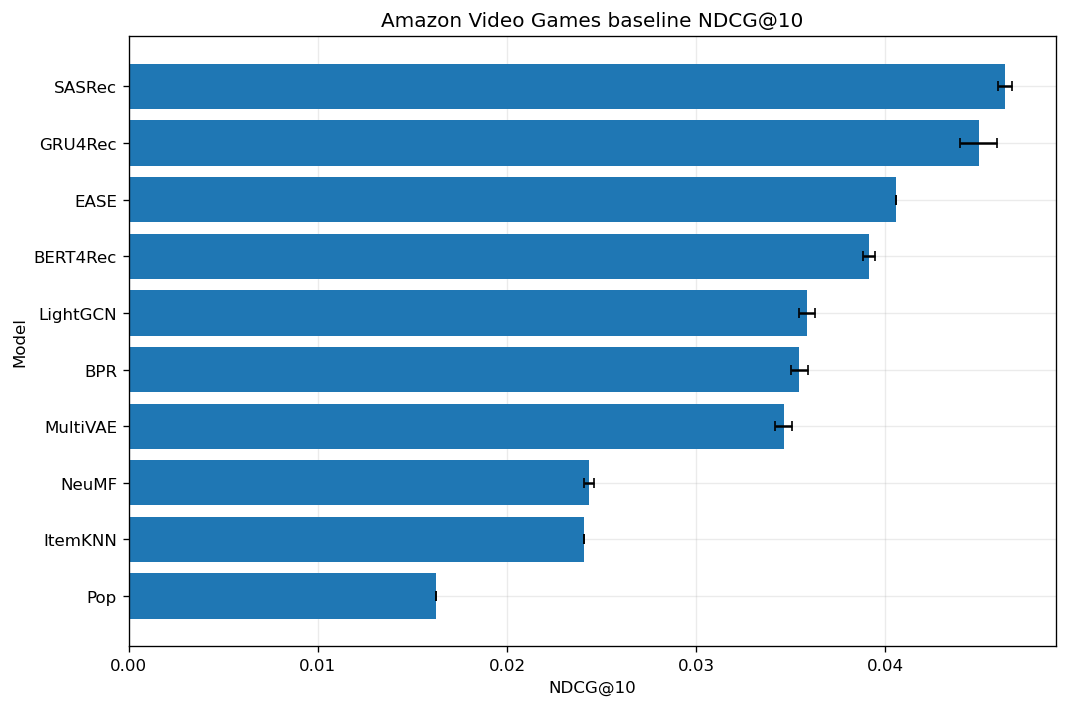

In [13]:
plot_baseline_metric(
    baseline_summary,
    dataset="amazon",
    metric="test_ndcg@10",
    metric_label="NDCG@10",
    title="Amazon Video Games baseline NDCG@10",
    filename="amazon_baseline_ndcg10",
)

## 4.3 Amazon Recall@10

Use Recall@10 to assess whether the main ranking conclusions are consistent with recommendation hit coverage.

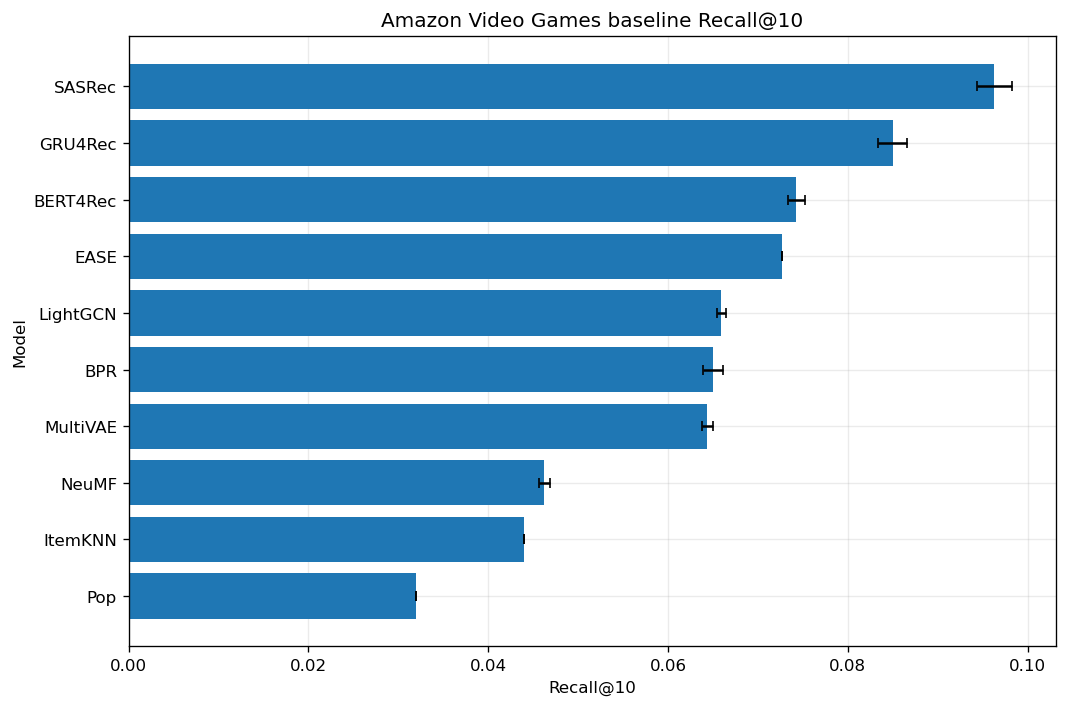

In [14]:
plot_baseline_metric(
    baseline_summary,
    dataset="amazon",
    metric="test_recall@10",
    metric_label="Recall@10",
    title="Amazon Video Games baseline Recall@10",
    filename="amazon_baseline_recall10",
)

## 4.4 Amazon MRR@10

Compare how highly the held-out test target is ranked when successfully retrieved.

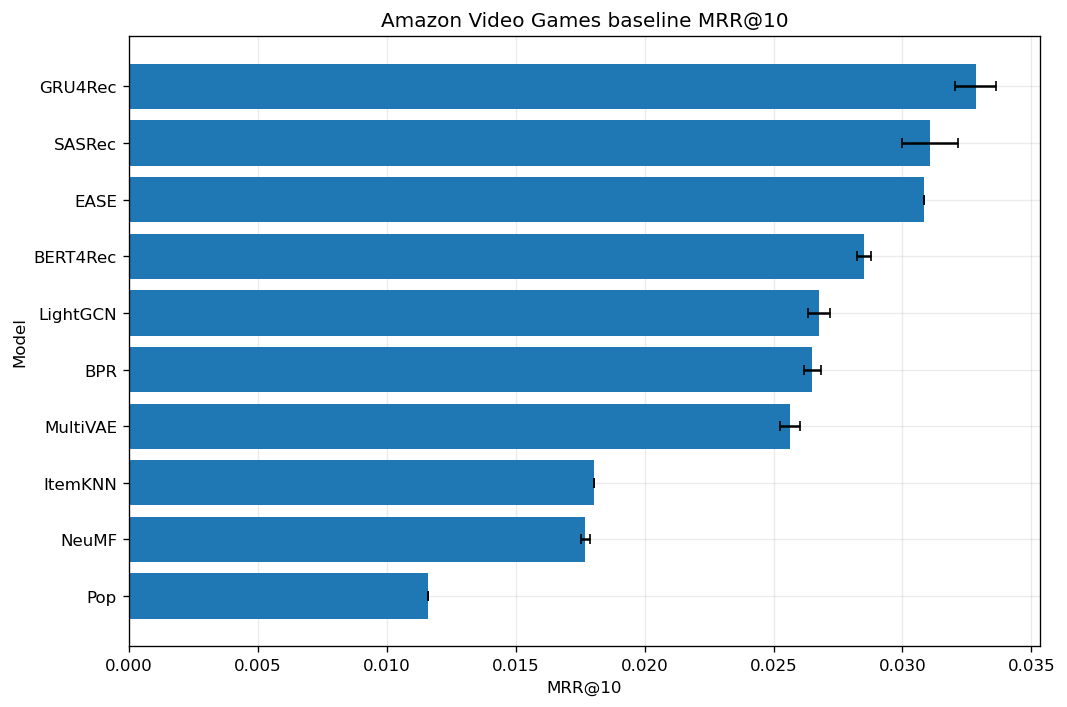

In [15]:
plot_baseline_metric(
    baseline_summary,
    dataset="amazon",
    metric="test_mrr@10",
    metric_label="MRR@10",
    title="Amazon Video Games baseline MRR@10",
    filename="amazon_baseline_mrr10",
)

## 4.5 Ranking consistency across K

Compare Amazon model rankings under NDCG@5, NDCG@10, and NDCG@20.

In [16]:
amazon_ndcg_k = create_rank_by_k_table(
    baseline,
    "amazon",
    metric="ndcg",
)

display(
    amazon_ndcg_k.style.format({
        "NDCG@5": "{:.6f}",
        "NDCG@10": "{:.6f}",
        "NDCG@20": "{:.6f}",
    })
)

,model,family,NDCG@5,NDCG@10,NDCG@20,Rank@5,Rank@10,Rank@20
0,SASRec,Sequential,0.034908,0.046315,0.057919,2,1,1
1,GRU4Rec,Sequential,0.034953,0.044938,0.055887,1,2,2
2,EASE,Linear,0.032719,0.040555,0.048094,3,3,4
3,BERT4Rec,Sequential,0.030387,0.039125,0.048845,4,4,3
4,LightGCN,Graph,0.028336,0.035857,0.043960,5,5,5
5,BPR,Classical,0.028151,0.035450,0.043304,6,6,6
6,MultiVAE,Neural,0.027229,0.034618,0.042207,7,7,7
7,NeuMF,Neural,0.018951,0.024331,0.030441,9,8,8
8,ItemKNN,Classical,0.019178,0.024051,0.029061,8,9,9
9,Pop,Non-personalized,0.011771,0.016255,0.019940,10,10,10


## 4.6 Seed variability

Examine run-to-run NDCG@10 variation for stochastic Amazon models.

In [17]:
amazon_seed_variability = (
    create_seed_variability_table(
        baseline_summary,
        "amazon",
    )
)

display(
    amazon_seed_variability.style.format({
        "test_ndcg@10_mean": "{:.6f}",
        "test_ndcg@10_std": "{:.6f}",
        "test_ndcg@10_min": "{:.6f}",
        "test_ndcg@10_max": "{:.6f}",
        "ndcg_range": "{:.6f}",
        "coefficient_of_variation_percent": "{:.2f}%",
    })
)

,model,model_family,runs,test_ndcg@10_mean,test_ndcg@10_std,test_ndcg@10_min,test_ndcg@10_max,ndcg_range,coefficient_of_variation_percent
0,GRU4Rec,Sequential,3,0.044938,0.000974,0.043828,0.045650,0.001822,2.17%
1,BPR,Classical,3,0.035450,0.000467,0.035025,0.035949,0.000924,1.32%
2,MultiVAE,Neural,3,0.034618,0.000439,0.034172,0.035049,0.000877,1.27%
3,LightGCN,Graph,3,0.035857,0.000431,0.035460,0.036316,0.000856,1.20%
4,SASRec,Sequential,3,0.046315,0.000368,0.046033,0.046731,0.000698,0.79%
5,BERT4Rec,Sequential,3,0.039125,0.000320,0.038812,0.039451,0.000639,0.82%
6,NeuMF,Neural,3,0.024331,0.000272,0.024018,0.024511,0.000493,1.12%


## 4.7 Amazon baseline findings

Record the main observations after reviewing the results:

- Which model achieves the highest NDCG@10?
- Which models form the strongest baseline group?
- Which simple or non-sequential model is strongest?
- Are the NDCG, Recall, and MRR rankings consistent?
- Are rankings stable across K?
- How stable are the stochastic models across seeds?
- How does the ranking differ from MovieLens?

These observations will later be converted into the Amazon baseline subsection of the Results chapter.

# 5. Cross-Dataset Baseline Comparison

## 5.1 Baseline model rankings

Compare each model's position on MovieLens and Amazon. Raw metric magnitudes are not treated as directly equivalent across datasets because the datasets have different sparsity, catalogue sizes, and user-history characteristics.

In [19]:
cross_dataset_ranks = (
    baseline_summary[
        [
            "dataset",
            "model",
            "model_family",
            "test_ndcg@10_mean",
            "test_ndcg@10_rank",
            "test_recall@10_mean",
            "test_recall@10_rank",
            "test_mrr@10_mean",
            "test_mrr@10_rank",
        ]
    ]
    .pivot(
        index=[
            "model",
            "model_family",
        ],
        columns="dataset",
    )
)


# Flatten MultiIndex columns.
cross_dataset_ranks.columns = [
    f"{metric}_{dataset}"
    for metric, dataset
    in cross_dataset_ranks.columns
]

cross_dataset_ranks = (
    cross_dataset_ranks
    .reset_index()
)


cross_dataset_ranks[
    "ndcg_rank_change_amazon_minus_movielens"
] = (
    cross_dataset_ranks[
        "test_ndcg@10_rank_amazon"
    ]
    - cross_dataset_ranks[
        "test_ndcg@10_rank_movielens"
    ]
)


cross_dataset_ranks = (
    cross_dataset_ranks
    .sort_values(
        "test_ndcg@10_rank_movielens"
    )
    .reset_index(drop=True)
)


display(
    cross_dataset_ranks.style.format({
        "test_ndcg@10_mean_movielens": "{:.6f}",
        "test_ndcg@10_mean_amazon": "{:.6f}",
        "test_recall@10_mean_movielens": "{:.6f}",
        "test_recall@10_mean_amazon": "{:.6f}",
        "test_mrr@10_mean_movielens": "{:.6f}",
        "test_mrr@10_mean_amazon": "{:.6f}",
    })
)

,model,model_family,test_ndcg@10_mean_amazon,test_ndcg@10_mean_movielens,test_ndcg@10_rank_amazon,test_ndcg@10_rank_movielens,test_recall@10_mean_amazon,test_recall@10_mean_movielens,test_recall@10_rank_amazon,test_recall@10_rank_movielens,test_mrr@10_mean_amazon,test_mrr@10_mean_movielens,test_mrr@10_rank_amazon,test_mrr@10_rank_movielens,ndcg_rank_change_amazon_minus_movielens
0,SASRec,Sequential,0.046315,0.119079,1,1,0.096300,0.223898,1,1,0.031080,0.087307,2,1,0
1,GRU4Rec,Sequential,0.044938,0.112553,2,2,0.084983,0.210032,2,3,0.032841,0.083042,1,2,0
2,BERT4Rec,Sequential,0.039125,0.106708,4,3,0.074291,0.212463,3,2,0.028502,0.074836,4,3,1
3,EASE,Linear,0.040555,0.045156,3,4,0.072666,0.090322,4,4,0.030816,0.031692,3,4,-1
4,MultiVAE,Neural,0.034618,0.039195,7,5,0.064361,0.081151,7,5,0.025627,0.026741,7,5,2
5,LightGCN,Graph,0.035857,0.038068,5,6,0.065933,0.079604,5,6,0.026761,0.025681,5,8,-1
6,BPR,Classical,0.035450,0.038047,6,7,0.065002,0.079218,6,7,0.026504,0.025787,6,7,-1
7,ItemKNN,Classical,0.024051,0.037286,9,8,0.043934,0.075572,9,8,0.018025,0.025903,8,6,1
8,NeuMF,Neural,0.024331,0.031950,8,9,0.046247,0.067120,8,9,0.017706,0.021448,9,9,-1
9,Pop,Non-personalized,0.016255,0.019158,10,10,0.032012,0.039443,10,10,0.011597,0.013127,10,10,0


## 5.2 NDCG@10 rank comparison

Create a compact table showing how each model's baseline position changes between the two datasets.

In [20]:
rank_comparison = cross_dataset_ranks[
    [
        "model",
        "model_family",
        "test_ndcg@10_rank_movielens",
        "test_ndcg@10_rank_amazon",
        "ndcg_rank_change_amazon_minus_movielens",
    ]
].copy()

rank_comparison.columns = [
    "Model",
    "Family",
    "MovieLens Rank",
    "Amazon Rank",
    "Rank Change",
]

display(rank_comparison)

,Model,Family,MovieLens Rank,Amazon Rank,Rank Change
0,SASRec,Sequential,1,1,0
1,GRU4Rec,Sequential,2,2,0
2,BERT4Rec,Sequential,3,4,1
3,EASE,Linear,4,3,-1
4,MultiVAE,Neural,5,7,2
5,LightGCN,Graph,6,5,-1
6,BPR,Classical,7,6,-1
7,ItemKNN,Classical,8,9,1
8,NeuMF,Neural,9,8,-1
9,Pop,Non-personalized,10,10,0


## 5.3 Baseline leaders

Summarise the highest-performing models and the strongest model within each recommendation family.

In [21]:
for dataset in ["movielens", "amazon"]:

    dataset_table = (
        baseline_summary[
            baseline_summary["dataset"]
            == dataset
        ]
        .sort_values(
            "test_ndcg@10_mean",
            ascending=False,
        )
    )

    winner = dataset_table.iloc[0]

    print("=" * 70)
    print(dataset.upper())
    print("=" * 70)

    print(
        f"Overall NDCG@10 winner: "
        f"{winner['model']} "
        f"({winner['test_ndcg@10_mean']:.6f})"
    )

    print("\nBest model within each family:")

    family_winners = (
        dataset_table
        .sort_values(
            "test_ndcg@10_mean",
            ascending=False,
        )
        .groupby(
            "model_family",
            as_index=False,
        )
        .first()
        [
            [
                "model_family",
                "model",
                "test_ndcg@10_mean",
            ]
        ]
        .sort_values(
            "test_ndcg@10_mean",
            ascending=False,
        )
    )

    display(
        family_winners.style.format({
            "test_ndcg@10_mean": "{:.6f}",
        })
    )

MOVIELENS
Overall NDCG@10 winner: SASRec (0.119079)

Best model within each family:


,model_family,model,test_ndcg@10_mean
5,Sequential,SASRec,0.119079
2,Linear,EASE,0.045156
3,Neural,MultiVAE,0.039195
1,Graph,LightGCN,0.038068
0,Classical,BPR,0.038047
4,Non-personalized,Pop,0.019158


AMAZON
Overall NDCG@10 winner: SASRec (0.046315)

Best model within each family:


,model_family,model,test_ndcg@10_mean
5,Sequential,SASRec,0.046315
2,Linear,EASE,0.040555
1,Graph,LightGCN,0.035857
0,Classical,BPR,0.035450
3,Neural,MultiVAE,0.034618
4,Non-personalized,Pop,0.016255


# 6. Export Results

## 6.1 Export baseline tables

Save the baseline summary tables so that later dissertation notebooks can use the same values without manually copying results.

In [22]:
baseline_summary.to_csv(
    TABLE_DIR / "baseline_summary_full.csv",
    index=False,
)

movielens_table.to_csv(
    TABLE_DIR / "movielens_baseline_summary.csv",
    index=False,
)

amazon_table.to_csv(
    TABLE_DIR / "amazon_baseline_summary.csv",
    index=False,
)

movielens_ndcg_k.to_csv(
    TABLE_DIR / "movielens_ndcg_rank_by_k.csv",
    index=False,
)

amazon_ndcg_k.to_csv(
    TABLE_DIR / "amazon_ndcg_rank_by_k.csv",
    index=False,
)

movielens_seed_variability.to_csv(
    TABLE_DIR / "movielens_seed_variability.csv",
    index=False,
)

amazon_seed_variability.to_csv(
    TABLE_DIR / "amazon_seed_variability.csv",
    index=False,
)

cross_dataset_ranks.to_csv(
    TABLE_DIR / "cross_dataset_baseline_comparison.csv",
    index=False,
)

rank_comparison.to_csv(
    TABLE_DIR / "cross_dataset_ndcg_rank_comparison.csv",
    index=False,
)


print("Baseline tables saved:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(f"  {path.relative_to(ROOT)}")

print("\nBaseline figures saved:")
for path in sorted(FIGURE_DIR.glob("*")):
    print(f"  {path.relative_to(ROOT)}")

Baseline tables saved:
  results\tables\baseline\amazon_baseline_summary.csv
  results\tables\baseline\amazon_ndcg_rank_by_k.csv
  results\tables\baseline\amazon_seed_variability.csv
  results\tables\baseline\baseline_summary_full.csv
  results\tables\baseline\cross_dataset_baseline_comparison.csv
  results\tables\baseline\cross_dataset_ndcg_rank_comparison.csv
  results\tables\baseline\movielens_baseline_summary.csv
  results\tables\baseline\movielens_ndcg_rank_by_k.csv
  results\tables\baseline\movielens_seed_variability.csv

Baseline figures saved:
  results\figures\baseline\amazon_baseline_mrr10.pdf
  results\figures\baseline\amazon_baseline_mrr10.png
  results\figures\baseline\amazon_baseline_ndcg10.pdf
  results\figures\baseline\amazon_baseline_ndcg10.png
  results\figures\baseline\amazon_baseline_recall10.pdf
  results\figures\baseline\amazon_baseline_recall10.png
  results\figures\baseline\movielens_baseline_mrr10.pdf
  results\figures\baseline\movielens_baseline_mrr10.png
  re

# 7. Baseline Analysis Summary

## 7.1 Final baseline status

Confirm that both datasets contain complete baseline summaries and identify the primary NDCG@10 winner for each dataset.

In [23]:
expected_models = set(MODEL_ORDER)

for dataset in ["movielens", "amazon"]:

    dataset_models = set(
        baseline_summary.loc[
            baseline_summary["dataset"]
            == dataset,
            "model",
        ]
    )

    assert dataset_models == expected_models


print("=" * 70)
print("BASELINE ANALYSIS COMPLETE")
print("=" * 70)

for dataset in ["movielens", "amazon"]:

    subset = (
        baseline_summary[
            baseline_summary["dataset"]
            == dataset
        ]
        .sort_values(
            "test_ndcg@10_mean",
            ascending=False,
        )
    )

    winner = subset.iloc[0]

    print(
        f"{dataset.capitalize():10s} | "
        f"NDCG@10 winner: {winner['model']} "
        f"({winner['test_ndcg@10_mean']:.6f})"
    )

print()
print(
    "Baseline tables and figures are ready for "
    "interpretation and later dissertation use."
)

BASELINE ANALYSIS COMPLETE
Movielens  | NDCG@10 winner: SASRec (0.119079)
Amazon     | NDCG@10 winner: SASRec (0.046315)

Baseline tables and figures are ready for interpretation and later dissertation use.
